In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("school_data.csv")

In [3]:
# Data Understanding
print("\n--- First 5 Rows ---")
print(df.head())

print("\n--- Dataset Info ---")
print(df.info())

print("\n--- Shape of Dataset ---")
print("Rows:", df.shape[0], "Columns:", df.shape[1])

print("\n--- Column Names ---")
print(df.columns)

print("\n--- Data Types ---")
print(df.dtypes)

print("\n--- Statistical Summary ---")
print(df.describe())

# Identify target variable (example: 'Score' or 'Marks')
target = 'Score' if 'Score' in df.columns else df.columns[-1]
print("\nTarget Variable:", target)



--- First 5 Rows ---
  School_ID    District     Block Urban_Rural  %_Math_Score  %_Language_Score  \
0     SCH_1  District_C  Block_C1       Rural         43.32             48.87   
1     SCH_2  District_A  Block_A3       Rural         81.98             83.18   
2     SCH_3  District_B  Block_B1       Rural         44.68             46.38   
3     SCH_4  District_A  Block_A1       Urban         44.86             35.20   
4     SCH_5  District_C  Block_C1       Rural         47.41             47.94   

   %_Science_Score  Teacher_Student_Ratio  Avg_Teacher_Experience_Years  \
0            48.89                   40.1                           5.7   
1            83.26                    NaN                           5.8   
2            40.19                   29.9                           7.1   
3            47.77                   24.6                           2.6   
4            50.99                   39.8                           6.1   

   Teacher_Trainings_Attended  Electrici

In [4]:
# Data Cleaning

# Check missing values
print("\n--- Missing Values ---")
print(df.isnull().sum())

# Handling missing values
# Numerical columns -> fill with mean
num_cols = df.select_dtypes(include=np.number).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].mean())

# Categorical columns -> fill with mode
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

print("\nMissing values after cleaning:")
print(df.isnull().sum())

# Remove duplicates
before = df.shape[0]
df.drop_duplicates(inplace=True)
after = df.shape[0]

print(f"\nDuplicates removed: {before - after}")


--- Missing Values ---
School_ID                          0
District                           0
Block                              0
Urban_Rural                        0
%_Math_Score                     258
%_Language_Score                   0
%_Science_Score                    0
Teacher_Student_Ratio            260
Avg_Teacher_Experience_Years       0
Teacher_Trainings_Attended         0
Electricity_Available              0
Internet_Available               260
Functional_Toilets                 0
Library_Available                  0
%_Marginalized_Students            0
%_Students_With_Home_Internet      0
Parent_Literacy_Rate             259
dtype: int64

Missing values after cleaning:
School_ID                        0
District                         0
Block                            0
Urban_Rural                      0
%_Math_Score                     0
%_Language_Score                 0
%_Science_Score                  0
Teacher_Student_Ratio            0
Avg_Teacher_Experience

C:\Users\saich\AppData\Local\Temp\ipykernel_1976\345356308.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)



--- Univariate Analysis ---


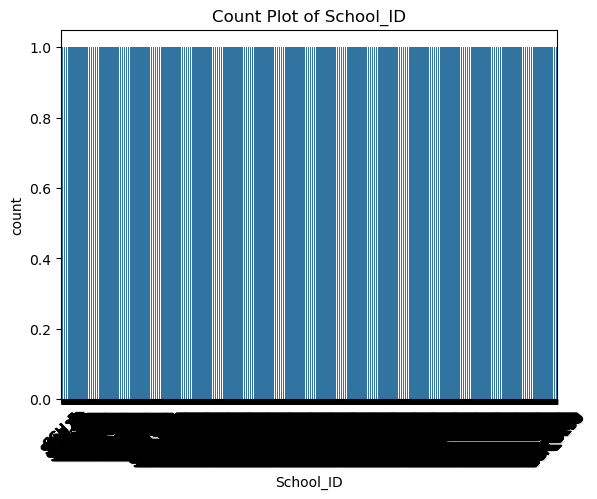

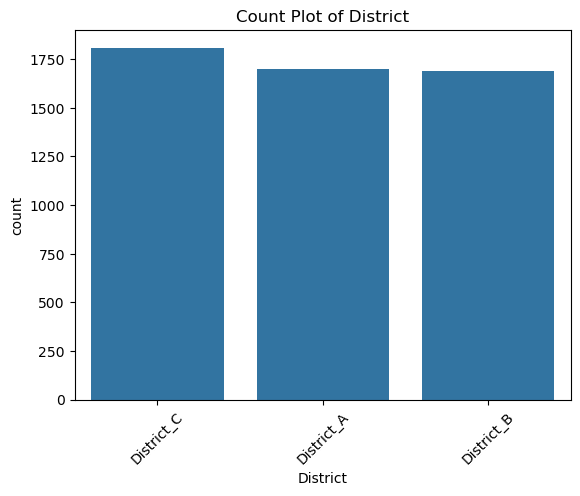

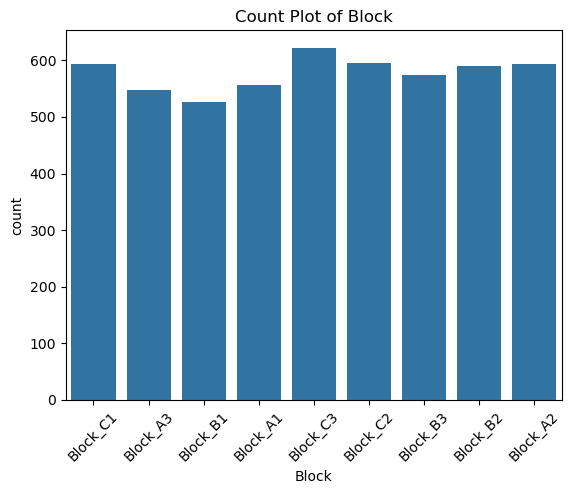

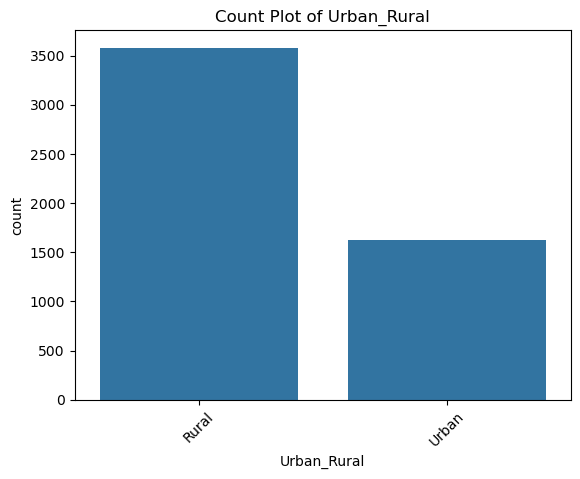

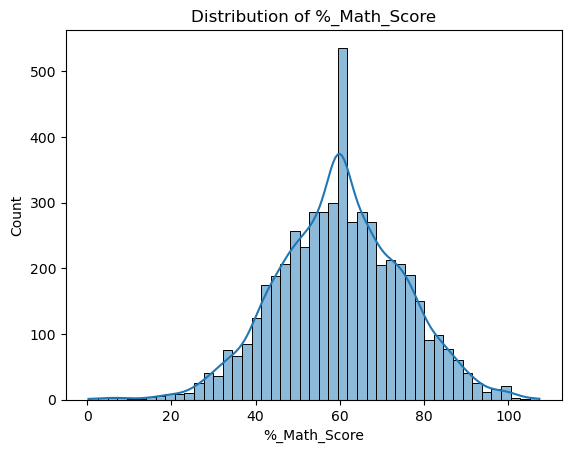

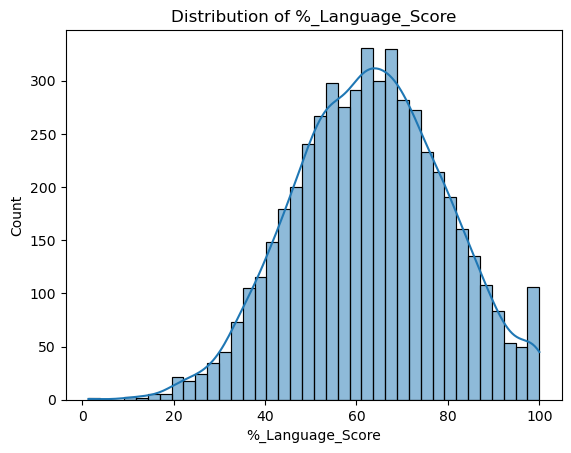

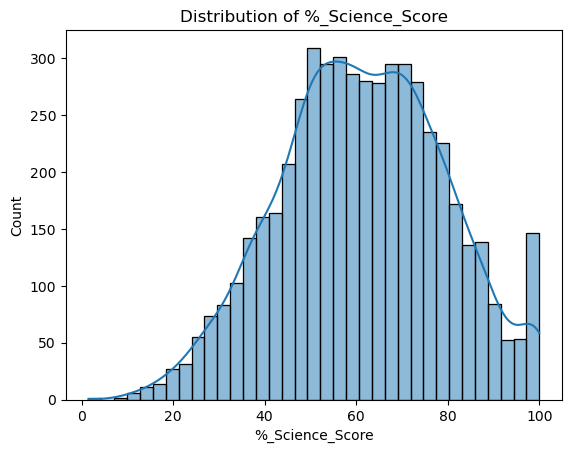

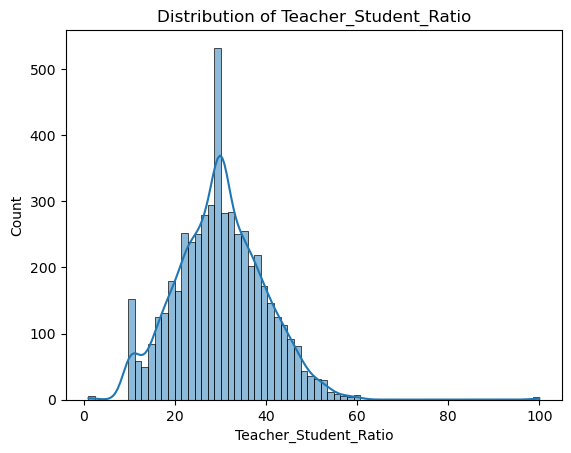

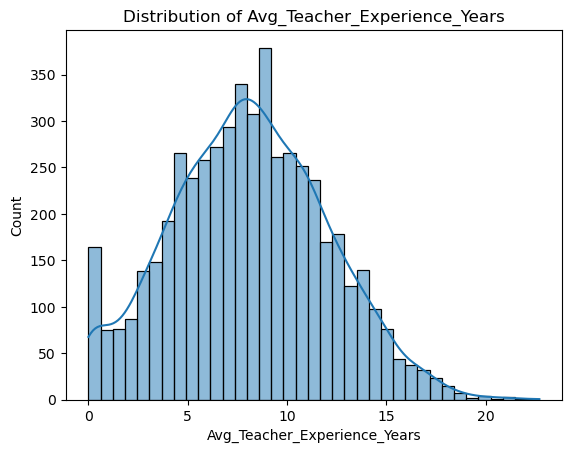

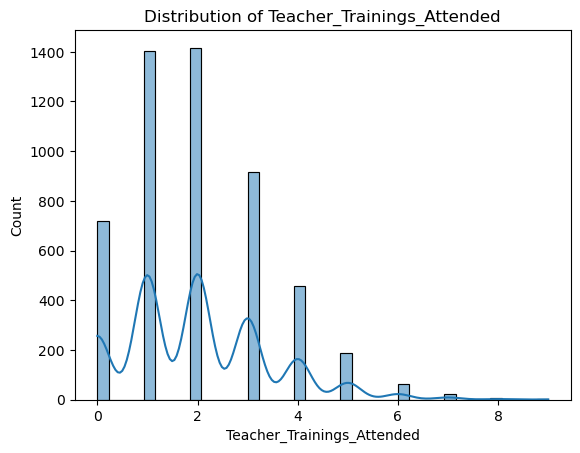

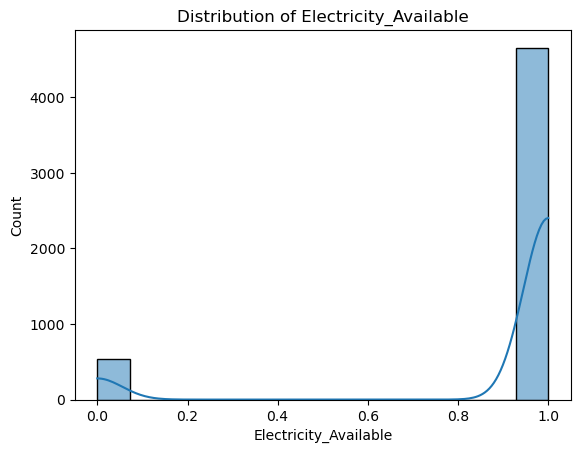

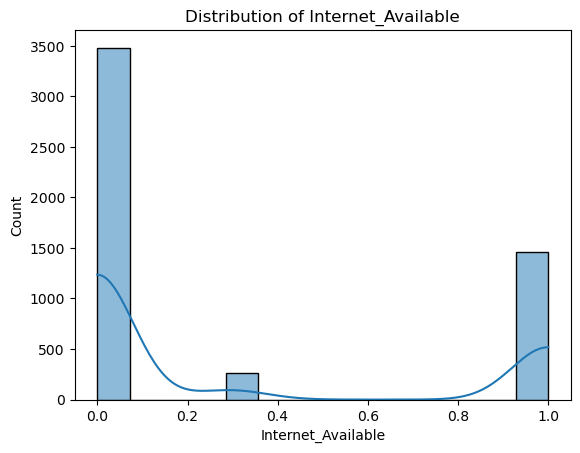

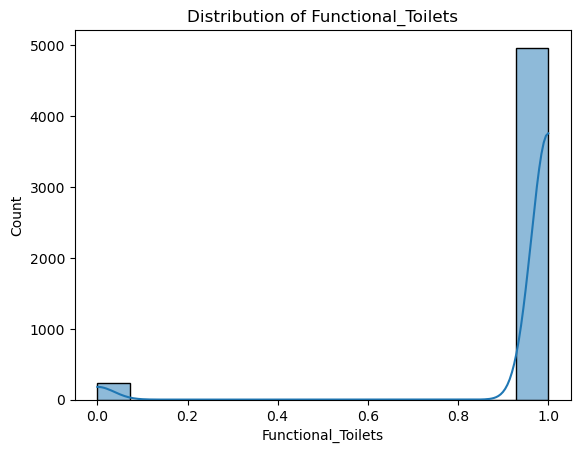

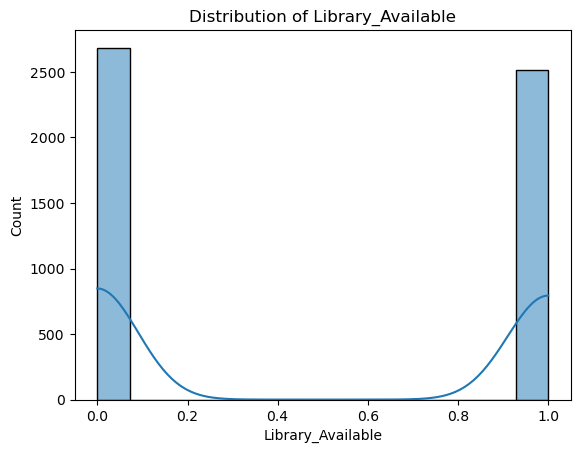

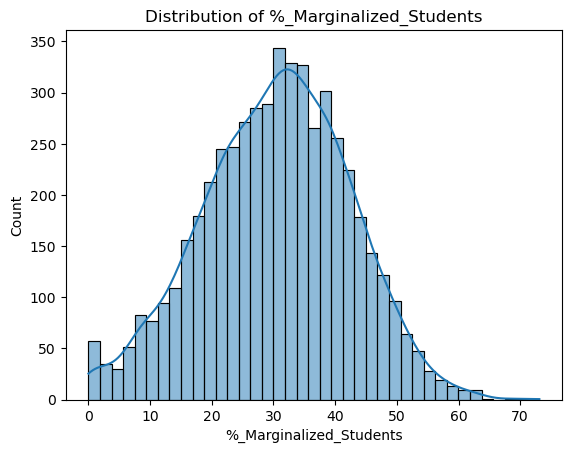

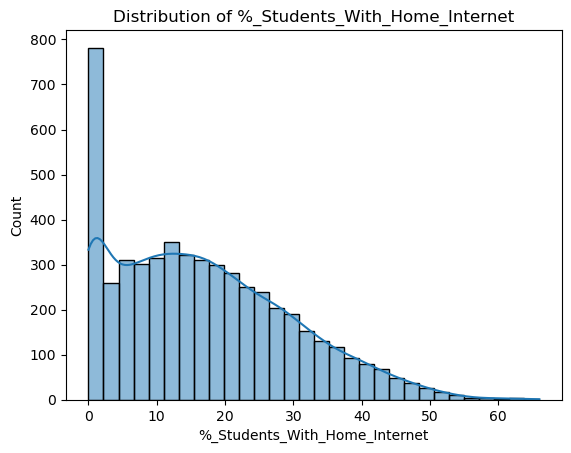

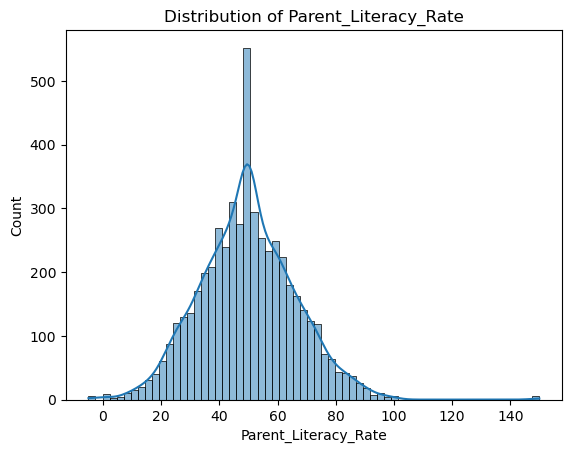

In [5]:
# Univariate Analysis

print("\n--- Univariate Analysis ---")

for col in df.columns:
    plt.figure()
    
    if df[col].dtype == 'object':
        sns.countplot(x=df[col])
        plt.title(f"Count Plot of {col}")
        plt.xticks(rotation=45)
    else:
        sns.histplot(df[col], kde=True)
        plt.title(f"Distribution of {col}")
    
    plt.show()



--- Bivariate Analysis ---


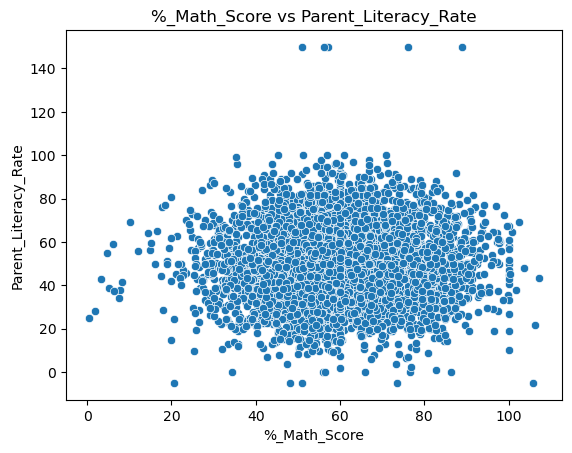

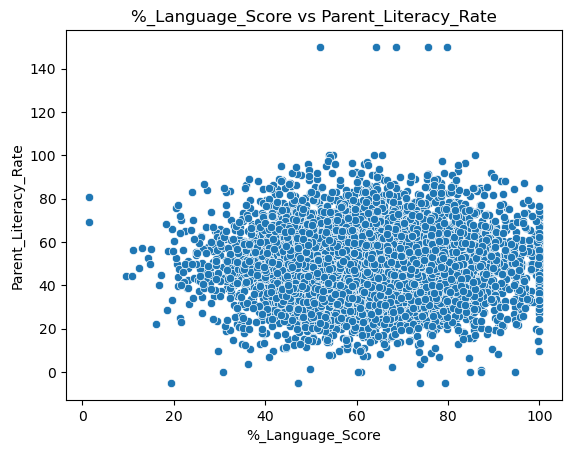

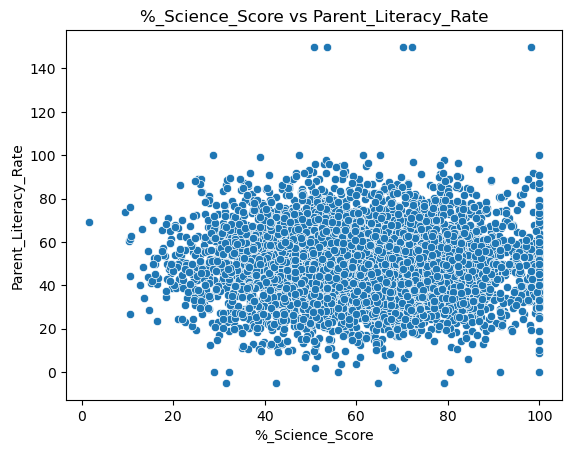

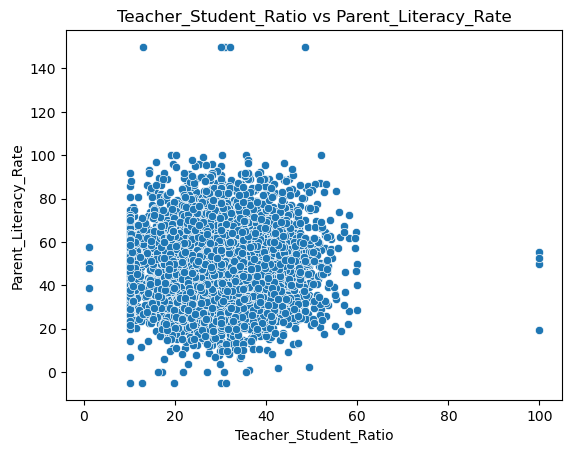

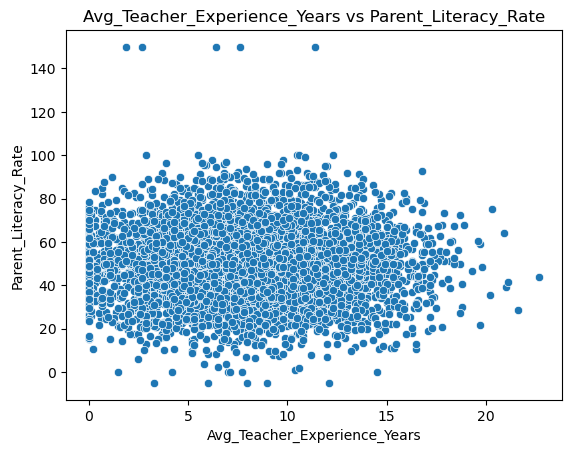

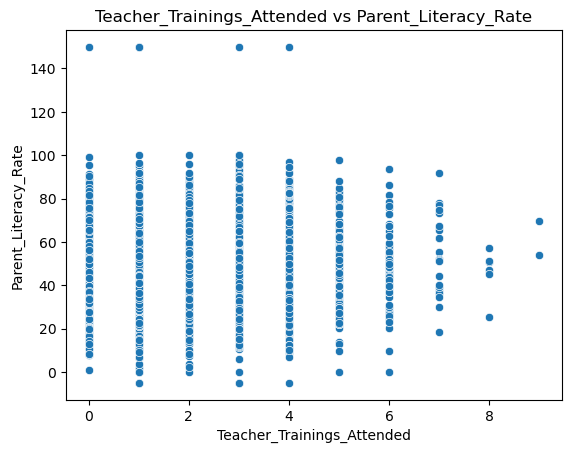

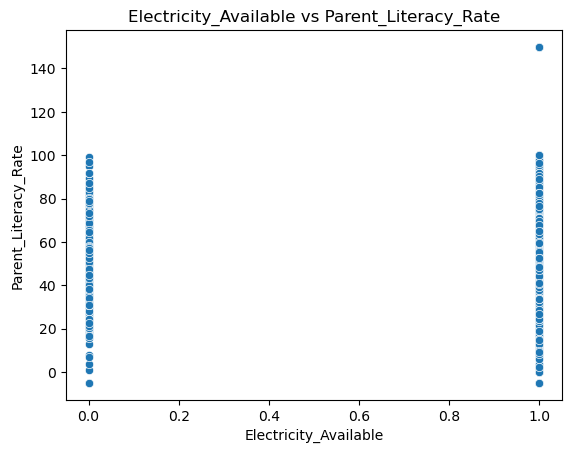

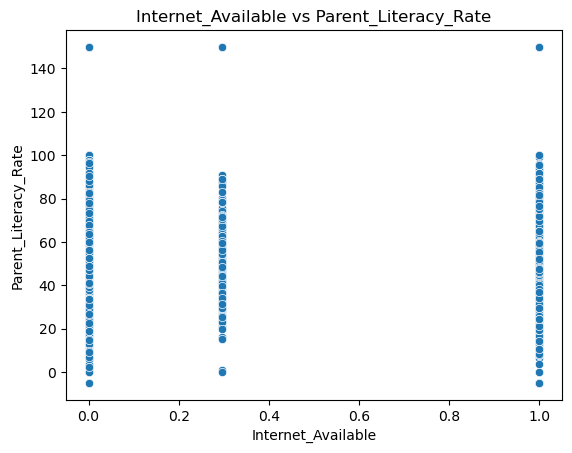

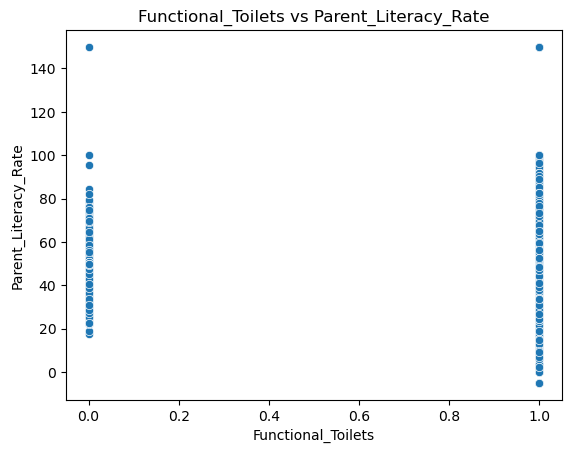

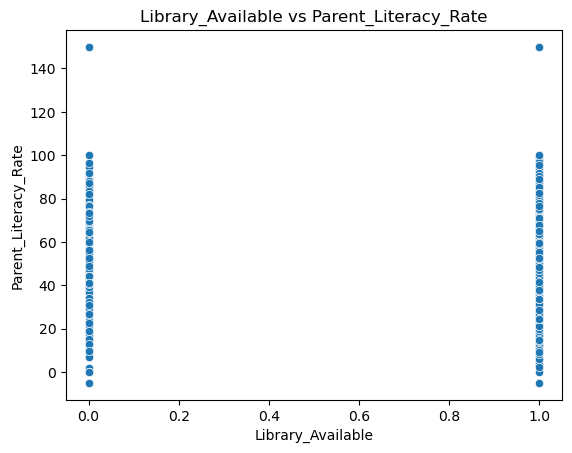

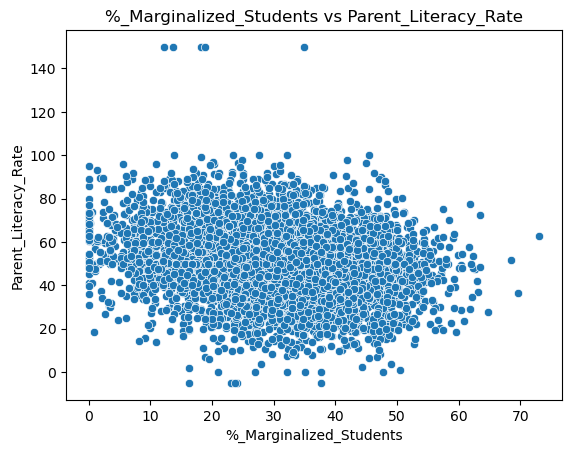

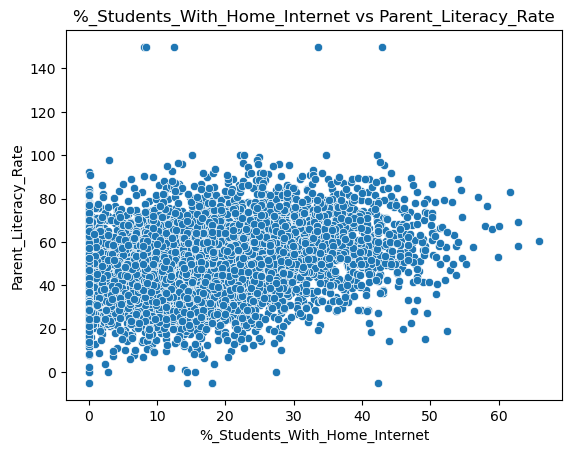

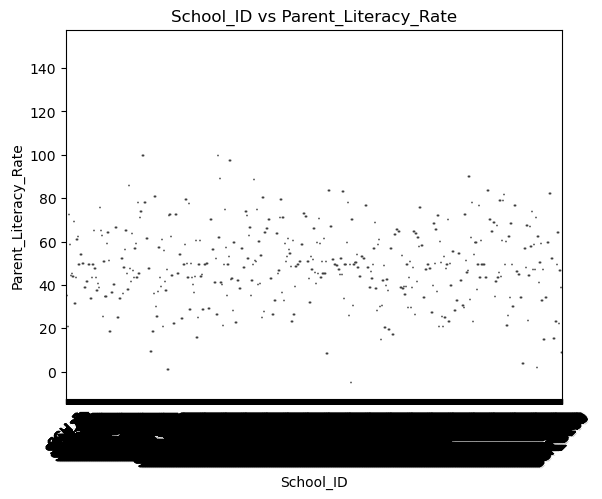

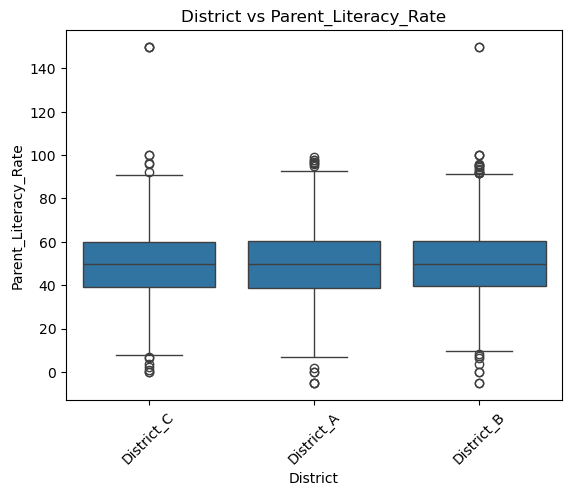

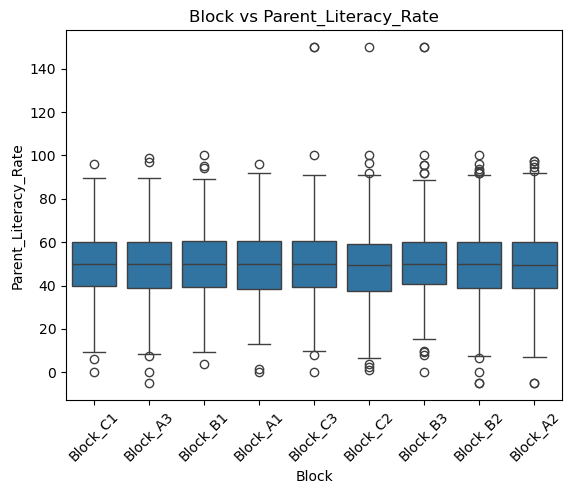

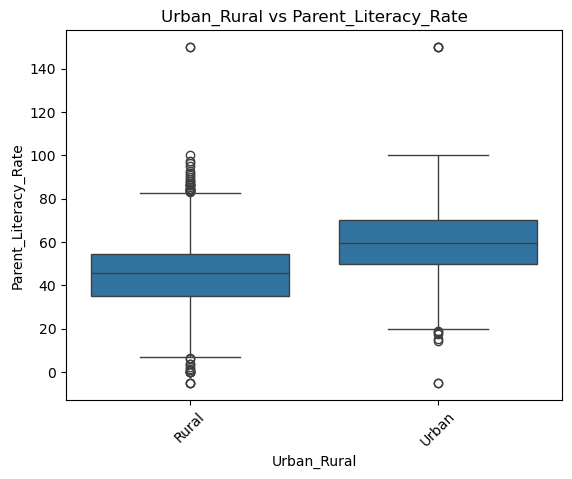

In [7]:
#Bivariate Analysis

print("\n--- Bivariate Analysis ---")

# Numerical vs Numerical
for col in num_cols:
    if col != target:
        plt.figure()
        sns.scatterplot(x=df[col], y=df[target])
        plt.title(f"{col} vs {target}")
        plt.show()

# Categorical vs Target
for col in cat_cols:
    plt.figure()
    sns.boxplot(x=df[col], y=df[target])
    plt.title(f"{col} vs {target}")
    plt.xticks(rotation=45)
    plt.show()



--- Correlation Matrix ---


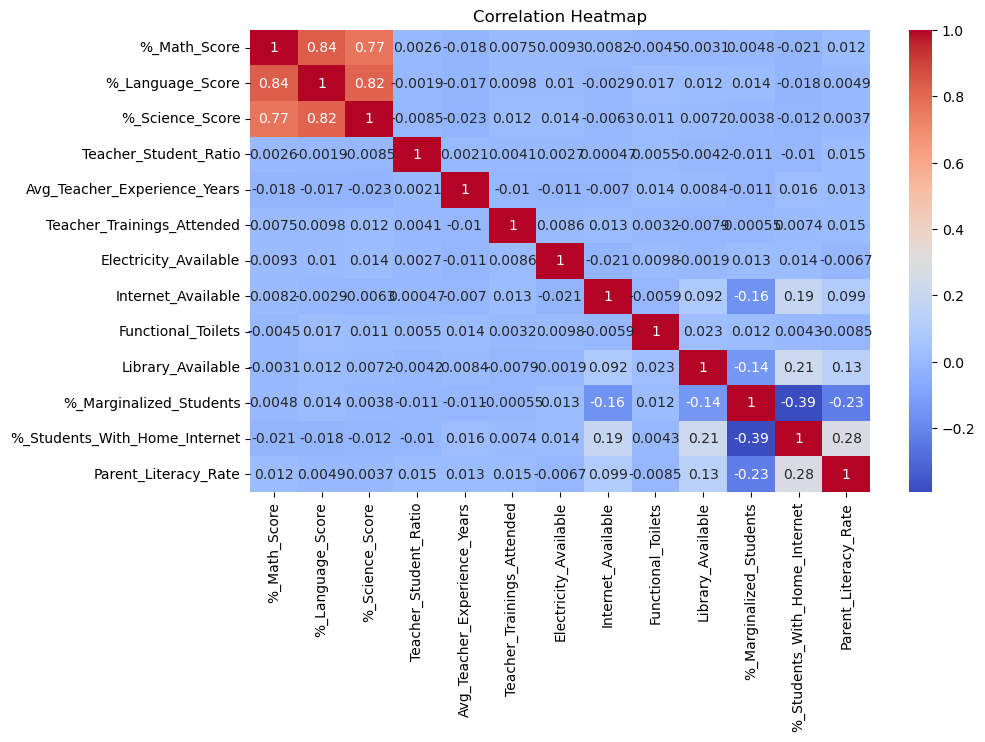

In [8]:
#Correlation Analysis

print("\n--- Correlation Matrix ---")

corr = df.corr(numeric_only=True)

plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [9]:
#Insights (Auto-generated basic)

print("\n--- Insights ---")

# 1. Highest correlated feature
corr_target = corr[target].sort_values(ascending=False)
print("Most positively correlated feature:", corr_target.index[1])
print("Most negatively correlated feature:", corr_target.index[-1])

# 2. Mean of target
print("Average Target Value:", df[target].mean())

# 3. Max and Min
print("Max Target:", df[target].max())
print("Min Target:", df[target].min())

# 4. Category with highest average target
if len(cat_cols) > 0:
    for col in cat_cols:
        print(f"\nAverage {target} by {col}:")
        print(df.groupby(col)[target].mean())

# 5. Outliers detection
for col in num_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    outliers = df[(df[col] < q1 - 1.5*iqr) | (df[col] > q3 + 1.5*iqr)]
    print(f"{col} Outliers:", len(outliers))


--- Insights ---
Most positively correlated feature: %_Students_With_Home_Internet
Most negatively correlated feature: %_Marginalized_Students
Average Target Value: 49.776644403966806
Max Target: 150.0
Min Target: -5.0

Average Parent_Literacy_Rate by School_ID:
School_ID
SCH_1       33.9
SCH_10      26.7
SCH_100     43.7
SCH_1000    66.4
SCH_1001    61.0
            ... 
SCH_995     57.8
SCH_996     41.6
SCH_997     36.9
SCH_998     66.4
SCH_999     74.2
Name: Parent_Literacy_Rate, Length: 5200, dtype: float64

Average Parent_Literacy_Rate by District:
District
District_A    49.848571
District_B    50.026944
District_C    49.475286
Name: Parent_Literacy_Rate, dtype: float64

Average Parent_Literacy_Rate by Block:
Block
Block_A1    50.278826
Block_A2    49.792945
Block_A3    49.471544
Block_B1    49.590979
Block_B2    49.673378
Block_B3    50.790632
Block_C1    50.013141
Block_C2    48.410963
Block_C3    49.980631
Name: Parent_Literacy_Rate, dtype: float64

Average Parent_Literacy_Rat

In [10]:
#Feature Engineering (Bonus)

# Example: create new feature
if len(num_cols) >= 2:
    df['Total'] = df[num_cols].sum(axis=1)
    print("\nNew Feature 'Total' created.")


New Feature 'Total' created.


In [11]:
# Basic Model (Bonus)

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# Convert categorical to numeric
df_model = pd.get_dummies(df, drop_first=True)

X = df_model.drop(target, axis=1)
y = df_model[target]

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model
model = LinearRegression()
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Evaluation
print("\n--- Model Performance ---")
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))


--- Model Performance ---
MAE: 0.0011444350570574417
R2 Score: 0.9999999887900073
